<a href="https://colab.research.google.com/github/dataguirre/curso-ia-ciencia-de-datos/blob/main/workshops/06-workshop-vlm-tiquetes-solucion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IA para ciencia de datos: Workshop 6 (soluciones)

En el Workshop 5 vimos que el OCR funciona bien con documentos de texto corrido escaneados en condiciones
razonables. Pero muchos documentos del día a día son **fotos tomadas con el celular**: con sombras, dedos,
perspectiva, sellos encima del texto y tablas con letra pequeña.

El Manual Operativo de Transportes del Llano (sección 7.3) pide que cada conductor **fotografíe el tiquete de
báscula** de la planta extractora y lo suba a RutaLlano. Alguien tiene que pasar esos datos a una tabla. En
este workshop vamos a automatizarlo con un **modelo de visión y lenguaje (VLM)**: un LLM que recibe imágenes.

1. Comprobar por qué el OCR con reglas no alcanza para estas fotos.
2. Extraer los campos con un VLM por API y obtener un JSON.
3. **Normalizar** los valores y **validarlos** con las reglas del propio tiquete.
4. Evaluar la extracción contra una transcripción manual.
5. (Opcional, con GPU) Probar un VLM pequeño corriendo en Colab.

Trabajamos con **15 fotos reales** de tiquetes de la Planta Extractora Sapuga, tomadas en agosto de 2026.

> **Antes de empezar:** sube `datos_workshop6.zip` a Colab y verifica que tu `GROQ_API_KEY` esté en Secrets.
> La GPU solo hace falta para la Actividad 5 (opcional).

### Configuración inicial

In [ ]:
# Colab carga algunas librerías al iniciar la sesión. Si la instalación las actualiza, la versión en memoria
# y la del disco quedan mezcladas y aparecen errores extraños (por ejemplo, "cannot import name '_Ink'").
# Esta verificación lo detecta y reinicia la sesión: si ves el aviso, vuelve a ejecutar esta celda.
import importlib.metadata
import os
import sys

_cargadas = {"pillow": "PIL", "numpy": "numpy"}
_antes = {paquete: sys.modules[modulo].__version__ for paquete, modulo in _cargadas.items() if modulo in sys.modules}
!apt-get -qq install -y tesseract-ocr tesseract-ocr-spa > /dev/null
!pip install -q pytesseract groq

_cambiadas = {p: (v, importlib.metadata.version(p)) for p, v in _antes.items() if importlib.metadata.version(p) != v}
if _cambiadas:
    print(f"⚠ La instalación actualizó {_cambiadas}.")
    print("⚠ La sesión se reiniciará. Cuando se reconecte, vuelve a ejecutar ESTA celda y continúa.")
    os.kill(os.getpid(), 9)

import base64
import io
import json
import re
import time
import zipfile
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pytesseract
from PIL import Image, ImageFilter

RUTA_ZIP = "datos_workshop6.zip"
with zipfile.ZipFile(RUTA_ZIP) as z:
    z.extractall(".")

DATOS = Path("datos_workshop6")
FOTOS = sorted((DATOS / "tiquetes").glob("*.jpg"))

CAMPOS_TEXTO = ["tiquete", "conductor", "cedula", "vehiculo", "nit_proveedor", "pto_descargue"]
CAMPOS_ENTEROS = ["remision", "ciclo", "racimos", "peso_bruto", "tara", "peso_neto", "muestra"]
CAMPOS_FECHA = ["fecha_entrada", "fecha_salida"]
CRITERIOS = ["maduro", "verde", "sobremaduro", "podrido", "pedunculo", "enfermo", "malformado"]
CAMPOS_CALIDAD = [f"{c}_{s}" for c in CRITERIOS for s in ("n", "pct")]
CAMPOS = CAMPOS_TEXTO + CAMPOS_FECHA + CAMPOS_ENTEROS + CAMPOS_CALIDAD

real = pd.read_csv(DATOS / "tiquetes.csv", dtype={c: str for c in CAMPOS_TEXTO + CAMPOS_FECHA},
                   keep_default_na=False).set_index("archivo")

print(f"✓ {len(FOTOS)} fotos")
print(f"✓ {len(real)} tiquetes transcritos, {len(CAMPOS)} campos por tiquete")
real.head(3)

✓ 15 fotos
✓ 15 tiquetes transcritos, 29 campos por tiquete


,tiquete,remision,fecha_entrada,fecha_salida,conductor,cedula,vehiculo,nit_proveedor,ciclo,racimos,...,sobremaduro_n,sobremaduro_pct,podrido_n,podrido_pct,pedunculo_n,pedunculo_pct,enfermo_n,enfermo_pct,malformado_n,malformado_pct
archivo,,,,,,,,,,,,,,,,,,,,,
tiquete_01.jpg,19605,558,2026-08-11 07:21:05,2026-08-11 07:32:15,JHON WILLIAM LESMES,7.062.561,TBZ488,900.285.103,1,1,...,22,26.19,1,1.19,1,1.19,0,0.0,0,0.0
tiquete_02.jpg,19666,559,2026-08-12 19:12:57,2026-08-12 19:24:36,JHON WILLIAM LESMES,7.062.561,TBZ488,900.285.103,0,0,...,10,11.90,0,0.00,2,2.38,0,0.0,0,0.0
tiquete_03.jpg,19722,561,2026-08-14 12:36:14,2026-08-14 12:47:27,JHON WILLIAM LESMES,7.062.561,TBZ488,900.285.103,0,0,...,9,10.71,0,0.00,0,0.00,0,0.0,0,0.0


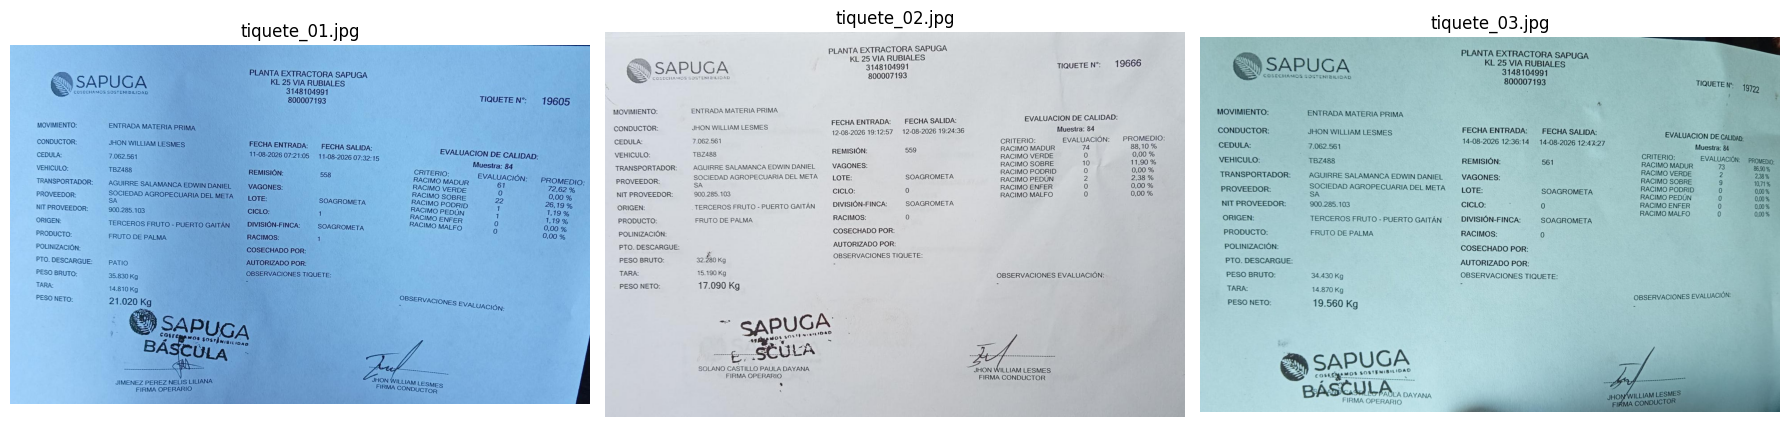

In [ ]:
fig, ejes = plt.subplots(1, 3, figsize=(18, 5))
for eje, ruta in zip(ejes, FOTOS[:3]):
    eje.imshow(Image.open(ruta))
    eje.set_title(ruta.name)
    eje.axis("off")
plt.tight_layout()
plt.show()

Mira con atención las fotos. Todos los tiquetes usan la misma plantilla, pero:

- el papel cambia de color y hay sombras, dedos y hojas dobladas;
- el sello de la báscula cae encima del nombre del operario;
- la tabla de **evaluación de calidad** tiene letra pequeña;
- los números usan el **formato colombiano**: `32.280 Kg` son treinta y dos mil kilos, y `88,10 %` usa coma
  decimal.

## Actividad 1: ¿Por qué no basta el OCR?

### Objetivo

La plantilla es fija, así que la idea más simple es: aplicar OCR y buscar cada campo con una expresión regular.
Probémoslo con dos campos: el número de tiquete y el peso neto.

In [ ]:
texto_ocr = pytesseract.image_to_string(Image.open(FOTOS[1]), lang="spa")
print(texto_ocr)

MOVIMIENTO:

CONDUCTOR:
CEDULA:
VEHICULO:
TRANSPORTADOR:
PROVEEDOR:

NIT PROVEEDOR:
ORIGEN:
PRODUCTO:
POLINIZACIÓN:
PTO. DESCARGUE:
PESO BRUTO:
TARA:

PESO NETO:

a

ENTRADA MATERIA PRIMA

JHON WILLIAM LESMES
7.062.561
TBZ488

AGUIRRE SALAMANCA EDWIN DANIEL

SOCIEDAD AGROPECUARIA DEL META
SA

900.285.103
TERCEROS FRUTO - PUERTO GAITÁN
FRUTO DE PALMA

4

32.280 Kg
15.190 Kg
17.090 Kg

da SApuSs

0330

SOLANO CASTILLO PAULA DAYANA
FIRMA OPERARIO
»

PLANTA EXTRACTORA SAPUGA
KL 25 VIA RUBIALES
3148104991
800007193

FECHA ENTRADA:
12-08-2026 19:12:57.

FECHA SALIDA:
12-08-2026 19:24:36

REMISIÓN: 559
VAGONES:

LOTE: SOAGROMETA
CICLO: o
DIVISIÓN-FINCA: — SOAGROMETA
RACIMOS: 0
COSECHADO POR:

AUTORIZADO POR:
OBSERVACIONES TIQUETE:

19666

TIQUETE N:
EVALUACION DE CALIDAD:
Muestra: 84
CRITERIO: EVALUACIÓN:

RACIMO MADUR
RACIMO VERDE
RACIMO SOBRE
RACIMO PODRID
RACIMO PEDÚN
RACIMO ENFER
RACIMO MALFO

OBSERVACIONES EVALUACIÓN:

ILLIAM LESMES

FIRMA CONDUCTOR

PROMEDIO:
88,10 %
0,00 %.
11,90 %
0,0

Fíjate en el orden: Tesseract lee la columna de **etiquetas** completa (`CONDUCTOR:`, `CEDULA:`, ...) y
**después** la columna de valores. El texto está, pero la relación "etiqueta → valor" se perdió.

#### Tarea 1: Extraer con expresiones regulares

Implementa `extraer_con_regex(texto)`.

### Requisitos

1. Devuelve un diccionario con las claves `"tiquete"` y `"peso_neto"`.
2. `tiquete`: los 5 dígitos que siguen a `TIQUETE N°`. Usa
   `r"TIQUETE\s*N\W*\s*(\d{5})"` sin distinguir mayúsculas (`re.IGNORECASE`).
3. `peso_neto`: el número que sigue a `PESO NETO` y antes de `Kg`, tal como aparece (por ejemplo `"17.090"`).
   Usa `r"PESO\s*NETO\W*\s*([\d.,]+)\s*K"`.
4. Si un patrón no encuentra nada, el valor es `None`.

In [ ]:
def extraer_con_regex(texto: str) -> dict:
    """Extrae el número de tiquete y el peso neto de un texto de OCR."""
    tiquete = re.search(r"TIQUETE\s*N\W*\s*(\d{5})", texto, re.IGNORECASE)
    peso = re.search(r"PESO\s*NETO\W*\s*([\d.,]+)\s*K", texto, re.IGNORECASE)
    return {
        "tiquete": tiquete.group(1) if tiquete else None,
        "peso_neto": peso.group(1) if peso else None,
    }

**Evaluación de implementación**

In [ ]:
# @title
# Celda de validación. No modificar.

def _validar_extraer_con_regex():
    if "extraer_con_regex" not in globals():
        print("✗ Todavía no existe 'extraer_con_regex'.")
        return

    casos = [
        ("TIQUETE N°: 19666\nPESO NETO: 17.090 Kg", {"tiquete": "19666", "peso_neto": "17.090"}),
        ("tiquete n° 20140 ... peso neto   23.610 kg", {"tiquete": "20140", "peso_neto": "23.610"}),
        ("PESO NETO:\nTARA:\n17.090 Kg", {"tiquete": None, "peso_neto": None}),
    ]
    fallas = []
    for texto, esperado in casos:
        try:
            obtenido = extraer_con_regex(texto)
        except Exception as e:
            print(f"✗ lanzó {type(e).__name__}: {e}")
            fallas.append(texto)
            continue
        if obtenido == esperado:
            print(f"✓ {texto!r:.45} → {obtenido}")
        else:
            print(f"✗ {texto!r:.45}\n    esperaba {esperado}\n    obtuvo   {obtenido}")
            fallas.append(texto)

    if not fallas:
        print("\n🎉 ¡Todo funciona correctamente!")


_validar_extraer_con_regex()

✓ 'TIQUETE N°: 19666\nPESO NETO: 17.090 Kg' → {'tiquete': '19666', 'peso_neto': '17.090'}
✓ 'tiquete n° 20140 ... peso neto   23.610 kg' → {'tiquete': '20140', 'peso_neto': '23.610'}
✓ 'PESO NETO:\nTARA:\n17.090 Kg' → {'tiquete': None, 'peso_neto': None}

🎉 ¡Todo funciona correctamente!


Ahora lo probamos en las 15 fotos (tarda menos de un minuto).

In [ ]:
filas = []
for ruta in FOTOS:
    extraido = extraer_con_regex(pytesseract.image_to_string(Image.open(ruta), lang="spa"))
    esperado = real.loc[ruta.name]
    peso = re.sub(r"\D", "", extraido["peso_neto"] or "")
    filas.append({
        "archivo": ruta.name,
        "tiquete_ocr": extraido["tiquete"],
        "tiquete_real": esperado["tiquete"],
        "peso_ocr": extraido["peso_neto"],
        "peso_real": esperado["peso_neto"],
        "tiquete_ok": extraido["tiquete"] == esperado["tiquete"],
        "peso_ok": peso == str(esperado["peso_neto"]),
    })

regex_df = pd.DataFrame(filas)
display(regex_df)
print(f"Tiquete correcto:   {regex_df['tiquete_ok'].sum()} de {len(regex_df)}")
print(f"Peso neto correcto: {regex_df['peso_ok'].sum()} de {len(regex_df)}")

,archivo,tiquete_ocr,tiquete_real,peso_ocr,peso_real,tiquete_ok,peso_ok
0,tiquete_01.jpg,80000,19605,None,21020,False,False
1,tiquete_02.jpg,None,19666,None,17090,False,False
2,tiquete_03.jpg,None,19722,None,19560,False,False
3,tiquete_04.jpg,19746,19746,None,18140,True,False
4,tiquete_05.jpg,None,19777,None,16340,False,False
5,tiquete_06.jpg,None,19813,17.960,17960,False,True
6,tiquete_07.jpg,None,19878,None,21320,False,False
7,tiquete_08.jpg,19906,19906,15.130,15130,True,True
8,tiquete_09.jpg,None,19910,18.330,18330,False,True
9,tiquete_10.jpg,19966,19966,None,19120,True,False


Tiquete correcto:   6 de 15
Peso neto correcto: 4 de 15


En nuestras pruebas, el número de tiquete salió bien en 6 de 15 fotos y el peso neto en 4. Y hay algo peor que
un `None`: en una foto la regex devolvió **un tiquete equivocado** (`80000`), tomado del NIT de la planta
(`800007193`). Un campo vacío se nota; un campo incorrecto pasa desapercibido.

Podríamos seguir afinando reglas (buscar por posición, usar `image_to_data`, enderezar la foto...), pero cada
foto nueva traería un caso distinto. Probemos otro enfoque.

## Actividad 2: VLM por API

### Objetivo

Un **VLM** recibe la imagen y el texto de la instrucción en el mismo mensaje. No separa "leer" de "entender":
ve la etiqueta y el valor juntos, igual que una persona.

Usaremos un modelo de visión de Groq. La API es la misma del Workshop 2; lo único que cambia es que el
`content` del mensaje ahora es una **lista** con partes de texto y de imagen.

> **Límites de la capa gratuita:** cada imagen cuenta como unos 2.000 tokens de entrada, y la capa gratuita
> permite pocos miles de tokens por minuto. Por eso haremos pausas entre llamadas y guardaremos los resultados
> en caché.

In [ ]:
from groq import BadRequestError, Groq, RateLimitError
from google.colab import userdata

# Groq cambia seguido sus modelos de visión, y este está en "preview".
# Si deja de funcionar, revisa https://console.groq.com/docs/vision y cambia este valor.
MODELO_VISION = "qwen/qwen3.8-27b"

client = Groq(api_key=userdata.get("GROQ_API_KEY"))
print("✓ Modelo de visión:", MODELO_VISION)

✓ Modelo de visión: qwen/qwen3.8-27b


#### Tarea 1: Preparar la imagen

Las APIs reciben las imágenes como texto en **base64**. Además, conviene enviarlas en un tamaño razonable:
Groq rechaza imágenes en base64 de más de 4 MB, y una foto enorme no mejora la lectura.

Implementa `imagen_a_base64(ruta, lado_maximo=1600, calidad=90)`.

### Requisitos

1. Abre la imagen y conviértela a RGB.
2. Redúcela con `imagen.thumbnail((lado_maximo, lado_maximo))`, que conserva la proporción y **nunca agranda**.
3. Guárdala como JPEG con esa `calidad` en un `io.BytesIO()`.
4. Devuelve `base64.b64encode(...).decode("utf-8")`.

In [ ]:
def imagen_a_base64(ruta, lado_maximo: int = 1600, calidad: int = 90) -> str:
    """Reduce una imagen y la codifica como JPEG en base64."""
    imagen = Image.open(ruta).convert("RGB")
    imagen.thumbnail((lado_maximo, lado_maximo))
    buffer = io.BytesIO()
    imagen.save(buffer, format="JPEG", quality=calidad)
    return base64.b64encode(buffer.getvalue()).decode("utf-8")

#### Tarea 2: Armar el mensaje multimodal

Implementa `construir_mensajes(imagen_b64, instrucciones)`.

### Requisitos

Devuelve una lista con **un** mensaje de rol `user` cuyo `content` es una lista con dos partes, en este orden:

```python
[
    {
        "role": "user",
        "content": [
            {"type": "text", "text": instrucciones},
            {"type": "image_url", "image_url": {"url": "data:image/jpeg;base64,<imagen_b64>"}},
        ],
    }
]
```

In [ ]:
def construir_mensajes(imagen_b64: str, instrucciones: str) -> list[dict]:
    """Arma un mensaje de usuario con texto e imagen."""
    return [
        {
            "role": "user",
            "content": [
                {"type": "text", "text": instrucciones},
                {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{imagen_b64}"}},
            ],
        }
    ]

#### Tarea 3: Leer el JSON de la respuesta

Le pediremos al modelo que responda solo con JSON, pero los modelos a veces lo envuelven en un bloque
```` ```json ````, o agregan una frase antes. Necesitamos un lector tolerante.

Implementa `parsear_json(texto)`.

### Requisitos

1. Busca el texto entre la **primera** `{` y la **última** `}` del texto.
2. Si no hay llaves, lanza `ValueError`.
3. Devuelve el resultado de `json.loads` sobre ese fragmento (si el JSON está mal formado, `json.loads` lanza
   un error que hereda de `ValueError`; déjalo pasar).

In [ ]:
def parsear_json(texto: str) -> dict:
    """Extrae y lee el objeto JSON contenido en un texto."""
    inicio, fin = texto.find("{"), texto.rfind("}")
    if inicio == -1 or fin <= inicio:
        raise ValueError("La respuesta no contiene un objeto JSON")
    return json.loads(texto[inicio:fin + 1])

**Evaluación de implementación**

In [ ]:
# @title
# Celda de validación. No modificar.

def _validar_actividad_2():
    funciones = ["imagen_a_base64", "construir_mensajes", "parsear_json"]
    faltan = [f for f in funciones if f not in globals()]
    if faltan:
        print(f"✗ Todavía no existen: {faltan}")
        return
    fallas = []

    # imagen_a_base64
    try:
        grande = base64.b64decode(imagen_a_base64(FOTOS[0], lado_maximo=800))
        chica_png = io.BytesIO()
        Image.new("RGBA", (100, 50), (255, 0, 0, 128)).save(chica_png, format="PNG")
        chica_png.seek(0)
        chica = base64.b64decode(imagen_a_base64(chica_png))
        img_grande, img_chica = Image.open(io.BytesIO(grande)), Image.open(io.BytesIO(chica))
        if img_grande.format == "JPEG" and max(img_grande.size) == 800:
            print(f"✓ imagen_a_base64 reduce la foto a 800 px de lado máximo: {img_grande.size}")
        else:
            print(f"✗ esperaba un JPEG de 800 px de lado máximo, obtuvo {img_grande.format} {img_grande.size}")
            fallas.append("reducir")
        if img_chica.size == (100, 50) and img_chica.mode == "RGB":
            print("✓ imagen_a_base64 no agranda imágenes pequeñas y convierte a RGB")
        else:
            print(f"✗ la imagen de 100×50 con transparencia quedó {img_chica.size} {img_chica.mode}")
            fallas.append("pequeña")
    except Exception as e:
        print(f"✗ imagen_a_base64 lanzó {type(e).__name__}: {e}")
        fallas.append("imagen")

    # construir_mensajes
    esperado = [{"role": "user", "content": [
        {"type": "text", "text": "hola"},
        {"type": "image_url", "image_url": {"url": "data:image/jpeg;base64,QUJD"}},
    ]}]
    try:
        obtenido = construir_mensajes("QUJD", "hola")
        if obtenido == esperado:
            print("✓ construir_mensajes arma el mensaje multimodal")
        else:
            print(f"✗ construir_mensajes\n    esperaba {esperado}\n    obtuvo   {obtenido}")
            fallas.append("mensajes")
    except Exception as e:
        print(f"✗ construir_mensajes lanzó {type(e).__name__}: {e}")
        fallas.append("mensajes")

    # parsear_json
    casos = [
        ('{"a": 1}', {"a": 1}),
        ('```json\n{"a": {"b": "2"}}\n```', {"a": {"b": "2"}}),
        ('Claro, aquí está: {"a": 1} ¡Listo!', {"a": 1}),
    ]
    for texto, esperado_json in casos:
        try:
            if parsear_json(texto) == esperado_json:
                print(f"✓ parsear_json({texto!r:.40})")
            else:
                print(f"✗ parsear_json({texto!r:.40}) no devolvió {esperado_json}")
                fallas.append("json")
        except Exception as e:
            print(f"✗ parsear_json({texto!r:.40}) lanzó {type(e).__name__}: {e}")
            fallas.append("json")
    for texto in ["no hay json", "} al revés {"]:
        try:
            parsear_json(texto)
            print(f"✗ parsear_json({texto!r}) debería lanzar ValueError")
            fallas.append("error")
        except ValueError:
            print(f"✓ parsear_json({texto!r}) lanza ValueError")
        except Exception as e:
            print(f"✗ parsear_json({texto!r}) lanzó {type(e).__name__} en vez de ValueError")
            fallas.append("error")

    if not fallas:
        print("\n🎉 ¡Todo funciona correctamente!")


_validar_actividad_2()

✓ imagen_a_base64 reduce la foto a 800 px de lado máximo: (800, 495)
✓ imagen_a_base64 no agranda imágenes pequeñas y convierte a RGB
✓ construir_mensajes arma el mensaje multimodal
✓ parsear_json('{"a": 1}')
✓ parsear_json('```json\n{"a": {"b": "2"}}\n```')
✓ parsear_json('Claro, aquí está: {"a": 1} ¡Listo!')
✓ parsear_json('no hay json') lanza ValueError
✓ parsear_json('} al revés {') lanza ValueError

🎉 ¡Todo funciona correctamente!


#### Tarea 4: La primera extracción

Este es el prompt. Fíjate en una decisión de diseño importante: le pedimos al modelo que **copie los valores
tal como aparecen impresos** (`"32.280 Kg"`, `"88,10 %"`) y no que los convierta a números. La conversión la
haremos nosotros en Python, en la Actividad 3. Así separamos lo que hace bien un modelo (leer) de lo que hace
mejor el código (convertir sin equivocarse).

In [ ]:
PROMPT_EXTRACCION = """Eres un sistema que transcribe tiquetes de báscula de una planta extractora de palma.
Devuelve SOLO un objeto JSON con exactamente estas claves. Copia cada valor tal como aparece impreso,
con sus puntos, comas, "%" y "Kg". Si un campo está vacío en el tiquete, usa "".

{
  "tiquete": "", "remision": "",
  "fecha_entrada": "", "fecha_salida": "",
  "conductor": "", "cedula": "", "vehiculo": "", "nit_proveedor": "",
  "ciclo": "", "racimos": "", "pto_descargue": "",
  "peso_bruto": "", "tara": "", "peso_neto": "",
  "muestra": "",
  "calidad": {
    "maduro": {"evaluacion": "", "promedio": ""},
    "verde": {"evaluacion": "", "promedio": ""},
    "sobremaduro": {"evaluacion": "", "promedio": ""},
    "podrido": {"evaluacion": "", "promedio": ""},
    "pedunculo": {"evaluacion": "", "promedio": ""},
    "enfermo": {"evaluacion": "", "promedio": ""},
    "malformado": {"evaluacion": "", "promedio": ""}
  }
}

En la tabla EVALUACION DE CALIDAD: RACIMO MADUR = maduro, RACIMO VERDE = verde,
RACIMO SOBRE = sobremaduro, RACIMO PODRID = podrido, RACIMO PEDÚN = pedunculo,
RACIMO ENFER = enfermo y RACIMO MALFO = malformado.
En "muestra" copia solo el número que aparece después de "Muestra:"."""


# Opciones de la llamada, de la preferida a la más simple. Si Groq rechaza una, se pasa a la siguiente.
OPCIONES_VLM = [
    {"response_format": {"type": "json_object"}, "reasoning_effort": "none"},
    {"response_format": {"type": "json_object"}, "reasoning_format": "hidden"},
    {},
]


def llamar_vlm(mensajes: list[dict], reintentos: int = 5) -> str:
    """Llama al modelo de visión, con reintentos si se alcanza el límite de uso."""
    global OPCIONES_VLM
    intentos = 0
    while True:
        try:
            respuesta = client.chat.completions.create(
                model=MODELO_VISION, messages=mensajes, temperature=0,
                max_completion_tokens=3000, **OPCIONES_VLM[0],
            )
            texto = respuesta.choices[0].message.content or ""
            return re.sub(r"<think>.*?</think>", "", texto, flags=re.DOTALL)
        except RateLimitError:
            intentos += 1
            if intentos > reintentos:
                raise RuntimeError("Groq sigue rechazando las solicitudes; espera un minuto y vuelve a intentar.")
            print(f"  (límite de Groq alcanzado, esperando {20 * intentos} s)")
            time.sleep(20 * intentos)
        except BadRequestError as e:
            if len(OPCIONES_VLM) == 1:
                raise
            print(f"  (el modelo no aceptó {list(OPCIONES_VLM[0])}; probando otra configuración)")
            OPCIONES_VLM = OPCIONES_VLM[1:]


def extraer_tiquete(ruta) -> dict:
    """Extrae los campos de la foto de un tiquete con el VLM."""
    mensajes = construir_mensajes(imagen_a_base64(ruta), PROMPT_EXTRACCION)
    return parsear_json(llamar_vlm(mensajes))


inicio = time.time()
crudo_ejemplo = extraer_tiquete(FOTOS[1])
print(f"({time.time() - inicio:.1f} s)\n")
print(json.dumps(crudo_ejemplo, ensure_ascii=False, indent=2))

(1.6 s)

{
  "tiquete": "19666",
  "remision": "559",
  "fecha_entrada": "12-08-2026 19:12:57",
  "fecha_salida": "12-08-2026 19:24:36",
  "conductor": "JHON WILLIAM LESMES",
  "cedula": "7.062.561",
  "vehiculo": "TBZ488",
  "nit_proveedor": "900.285.103",
  "ciclo": "0",
  "racimos": "0",
  "pto_descargue": "",
  "peso_bruto": "32.280 Kg",
  "tara": "15.190 Kg",
  "peso_neto": "17.090 Kg",
  "muestra": "84",
  "calidad": {
    "maduro": {
      "evaluacion": "74",
      "promedio": "88,10 %"
    },
    "verde": {
      "evaluacion": "0",
      "promedio": "0,00 %"
    },
    "sobremaduro": {
      "evaluacion": "10",
      "promedio": "11,90 %"
    },
    "podrido": {
      "evaluacion": "0",
      "promedio": "0,00 %"
    },
    "pedunculo": {
      "evaluacion": "2",
      "promedio": "2,38 %"
    },
    "enfermo": {
      "evaluacion": "0",
      "promedio": "0,00 %"
    },
    "malformado": {
      "evaluacion": "0",
      "promedio": "0,00 %"
    }
  }
}


Compara con la foto. En la mayoría de los casos el resultado es impresionante: el modelo relaciona cada
etiqueta con su valor y lee la tabla de calidad. Pero todavía no podemos **usar** este JSON: los pesos son
texto con puntos y `Kg`, las fechas vienen en formato día-mes-año y no sabemos si algún número se leyó mal.

## Actividad 3: Normalizar y validar

### Objetivo

Convertir lo que el modelo copió en valores útiles y, sobre todo, **detectar errores sin conocer la respuesta
correcta**. En producción no tendremos una transcripción manual para comparar; tenemos que confiar en las reglas
del propio documento.

#### Tarea 1: Números en formato colombiano

Implementa `normalizar_numero_co(texto)`.

### Requisitos

1. En Colombia, el punto separa miles: `"32.280 Kg"` es `32280`.
2. Ignora unidades y espacios: devuelve un `int` formado por los dígitos del texto.
3. Si el texto tiene una coma (`"1,5"`), no es un entero: lanza `ValueError`.
4. Si el texto no tiene dígitos, lanza `ValueError`.

In [ ]:
def normalizar_numero_co(texto: str) -> int:
    """Convierte un entero impreso en formato colombiano ("32.280 Kg") a int."""
    texto = str(texto)
    if "," in texto:
        raise ValueError(f"{texto!r} no es un entero")
    digitos = re.sub(r"\D", "", texto)
    if not digitos:
        raise ValueError(f"{texto!r} no contiene dígitos")
    return int(digitos)

#### Tarea 2: Porcentajes

Implementa `normalizar_porcentaje(texto)`.

### Requisitos

1. Quita el símbolo `%` y los espacios.
2. Si el texto tiene coma, la coma es el separador decimal y los puntos son de miles:
   `"1.234,5"` → `1234.5`, `"88,10 %"` → `88.1`.
3. Si no tiene coma, conviértelo directamente: `"96.05"` → `96.05`, `"0"` → `0.0`.
4. Devuelve un `float`. Si el texto no se puede convertir, `float()` lanza `ValueError`; déjalo pasar.

In [ ]:
def normalizar_porcentaje(texto: str) -> float:
    """Convierte un porcentaje impreso ("88,10 %") a float."""
    texto = str(texto).replace("%", "").replace(" ", "")
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    return float(texto)

#### Tarea 3: Fechas

Implementa `normalizar_fecha(texto)`.

### Requisitos

1. El tiquete imprime las fechas como `"12-08-2026 19:12:57"` (día-mes-año).
2. Devuelve el formato ISO `"2026-08-12 19:12:57"`, que se ordena bien como texto.
3. Usa `datetime.strptime(texto.strip(), "%d-%m-%Y %H:%M:%S")`; si la fecha no existe (por ejemplo, mes 13),
   `strptime` lanza `ValueError`.

In [ ]:
def normalizar_fecha(texto: str) -> str:
    """Convierte "12-08-2026 19:12:57" en "2026-08-12 19:12:57"."""
    fecha = datetime.strptime(str(texto).strip(), "%d-%m-%Y %H:%M:%S")
    return fecha.strftime("%Y-%m-%d %H:%M:%S")

**Evaluación de implementación**

In [ ]:
# @title
# Celda de validación. No modificar.

def _validar_normalizacion():
    funciones = ["normalizar_numero_co", "normalizar_porcentaje", "normalizar_fecha"]
    faltan = [f for f in funciones if f not in globals()]
    if faltan:
        print(f"✗ Todavía no existen: {faltan}")
        return
    fallas = []

    def _probar(funcion, entrada, esperado):
        nombre = funcion.__name__
        try:
            obtenido = funcion(entrada)
        except Exception as e:
            print(f"✗ {nombre}({entrada!r}) lanzó {type(e).__name__}: {e}")
            fallas.append(nombre)
            return
        if obtenido == esperado and type(obtenido) is type(esperado):
            print(f"✓ {nombre}({entrada!r}) = {obtenido!r}")
        else:
            print(f"✗ {nombre}({entrada!r}): esperaba {esperado!r}, obtuvo {obtenido!r}")
            fallas.append(nombre)

    def _error(funcion, entrada):
        nombre = funcion.__name__
        try:
            funcion(entrada)
        except ValueError:
            print(f"✓ {nombre}({entrada!r}) lanza ValueError")
        except Exception as e:
            print(f"✗ {nombre}({entrada!r}) lanzó {type(e).__name__} en vez de ValueError")
            fallas.append(nombre)
        else:
            print(f"✗ {nombre}({entrada!r}) debería lanzar ValueError")
            fallas.append(nombre)

    _probar(normalizar_numero_co, "32.280 Kg", 32280)
    _probar(normalizar_numero_co, "684", 684)
    _probar(normalizar_numero_co, " 1.234.567 ", 1234567)
    _error(normalizar_numero_co, "1,5")
    _error(normalizar_numero_co, "")

    _probar(normalizar_porcentaje, "88,10 %", 88.1)
    _probar(normalizar_porcentaje, "0,00%", 0.0)
    _probar(normalizar_porcentaje, "1.234,5", 1234.5)
    _probar(normalizar_porcentaje, "96.05", 96.05)
    _error(normalizar_porcentaje, "abc %")

    _probar(normalizar_fecha, "12-08-2026 19:12:57", "2026-08-12 19:12:57")
    _probar(normalizar_fecha, " 01-12-2026 07:05:00 ", "2026-12-01 07:05:00")
    _error(normalizar_fecha, "12-13-2026 19:12:57")

    if not fallas:
        print("\n🎉 ¡Todo funciona correctamente!")


_validar_normalizacion()

✓ normalizar_numero_co('32.280 Kg') = 32280
✓ normalizar_numero_co('684') = 684
✓ normalizar_numero_co(' 1.234.567 ') = 1234567
✓ normalizar_numero_co('1,5') lanza ValueError
✓ normalizar_numero_co('') lanza ValueError
✓ normalizar_porcentaje('88,10 %') = 88.1
✓ normalizar_porcentaje('0,00%') = 0.0
✓ normalizar_porcentaje('1.234,5') = 1234.5
✓ normalizar_porcentaje('96.05') = 96.05
✓ normalizar_porcentaje('abc %') lanza ValueError
✓ normalizar_fecha('12-08-2026 19:12:57') = '2026-08-12 19:12:57'
✓ normalizar_fecha(' 01-12-2026 07:05:00 ') = '2026-12-01 07:05:00'
✓ normalizar_fecha('12-13-2026 19:12:57') lanza ValueError

🎉 ¡Todo funciona correctamente!


Con las tres funciones, esta función convierte la respuesta del modelo en una fila con las mismas columnas de
`tiquetes.csv`. Si un valor no se puede convertir, queda como `None` en vez de detener todo el proceso.

In [ ]:
def _seguro(funcion, valor):
    try:
        return funcion(valor)
    except (ValueError, TypeError, AttributeError):
        return None


def normalizar_tiquete(crudo: dict) -> dict:
    """Convierte la respuesta del VLM en una fila con valores normalizados."""
    fila = {c: str(crudo.get(c) or "").strip().upper() for c in CAMPOS_TEXTO}
    fila.update({c: _seguro(normalizar_fecha, crudo.get(c)) for c in CAMPOS_FECHA})
    fila.update({c: _seguro(normalizar_numero_co, crudo.get(c)) for c in CAMPOS_ENTEROS})
    calidad = crudo.get("calidad") or {}
    for criterio in CRITERIOS:
        valores = calidad.get(criterio) or {}
        fila[f"{criterio}_n"] = _seguro(normalizar_numero_co, valores.get("evaluacion"))
        fila[f"{criterio}_pct"] = _seguro(normalizar_porcentaje, valores.get("promedio"))
    return fila


pd.DataFrame([normalizar_tiquete(crudo_ejemplo)]).T.rename(columns={0: "valor"})

,valor
tiquete,19666
conductor,JHON WILLIAM LESMES
cedula,7.062.561
vehiculo,TBZ488
nit_proveedor,900.285.103
pto_descargue,
fecha_entrada,2026-08-12 19:12:57
fecha_salida,2026-08-12 19:24:36
remision,559
ciclo,0


#### Tarea 4: Validar con las reglas del tiquete

El tiquete trae sus propios controles. Revisando las 15 transcripciones encontramos estas reglas, que se
cumplen en **todos** los tiquetes:

- **Pesos:** `peso_bruto - tara == peso_neto`.
- **Porcentajes:** para cada criterio, `n / muestra * 100` redondeado a 2 decimales es igual al porcentaje
  impreso.
- **Madurez:** `maduro + verde + sobremaduro + podrido == muestra`. Pedúnculo, enfermo y malformado son
  defectos **adicionales**, que se cuentan aparte.
- **Tiempos:** la fecha de salida es posterior a la de entrada.

Implementa `validar_tiquete(t)`.

### Requisitos

1. Recibe una fila normalizada (como la de `normalizar_tiquete`) y devuelve una `list[str]` con los problemas
   encontrados. Una lista vacía significa que el tiquete pasó todas las reglas.
2. Primero, por cada campo de `CAMPOS_FECHA`, `CAMPOS_ENTEROS` y `CAMPOS_CALIDAD` que sea `None`, agrega
   `"falta <campo>"`.
3. Luego aplica cada regla **solo si sus campos existen**, y agrega un mensaje que empiece con:
   - `"pesos"` si falla la regla de pesos;
   - `"porcentaje <criterio>"` si el porcentaje de ese criterio difiere en más de `0.01`;
   - `"madurez"` si falla la suma de madurez;
   - `"tiempos"` si la salida no es posterior a la entrada.
4. Si `muestra` es 0, no apliques las reglas de porcentajes ni de madurez (y agrega `"muestra en cero"`).

In [ ]:
def validar_tiquete(t: dict) -> list[str]:
    """Revisa un tiquete normalizado con las reglas del documento."""
    problemas = [f"falta {c}" for c in CAMPOS_FECHA + CAMPOS_ENTEROS + CAMPOS_CALIDAD if t.get(c) is None]

    if None not in (t.get("peso_bruto"), t.get("tara"), t.get("peso_neto")):
        if t["peso_bruto"] - t["tara"] != t["peso_neto"]:
            problemas.append(f"pesos: {t['peso_bruto']} - {t['tara']} ≠ {t['peso_neto']}")

    muestra = t.get("muestra")
    if muestra == 0:
        problemas.append("muestra en cero")
    elif muestra is not None:
        for criterio in CRITERIOS:
            n, pct = t.get(f"{criterio}_n"), t.get(f"{criterio}_pct")
            if n is not None and pct is not None and abs(round(100 * n / muestra, 2) - pct) > 0.01:
                problemas.append(f"porcentaje {criterio}: {n}/{muestra} ≠ {pct} %")

        madurez = [t.get(f"{c}_n") for c in ["maduro", "verde", "sobremaduro", "podrido"]]
        if None not in madurez and sum(madurez) != muestra:
            problemas.append(f"madurez: {' + '.join(map(str, madurez))} ≠ {muestra}")

    if None not in (t.get("fecha_entrada"), t.get("fecha_salida")):
        if t["fecha_salida"] <= t["fecha_entrada"]:
            problemas.append(f"tiempos: salida {t['fecha_salida']} no es posterior a {t['fecha_entrada']}")

    return problemas

**Evaluación de implementación**

In [ ]:
# @title
# Celda de validación. No modificar.

def _tiquete_valido():
    fila = real.iloc[0].to_dict()
    return {c: fila[c] for c in CAMPOS}


def _validar_validar_tiquete():
    if "validar_tiquete" not in globals():
        print("✗ Todavía no existe 'validar_tiquete'.")
        return
    fallas = []

    def _probar(descripcion, cambios, prefijos_esperados):
        t = _tiquete_valido()
        t.update(cambios)
        try:
            problemas = validar_tiquete(t)
        except Exception as e:
            print(f"✗ {descripcion}: lanzó {type(e).__name__}: {e}")
            fallas.append(descripcion)
            return
        encontrados = sorted(p.split(":")[0] for p in problemas)
        if encontrados == sorted(prefijos_esperados):
            print(f"✓ {descripcion} → {problemas if problemas else 'sin problemas'}")
        else:
            print(f"✗ {descripcion}\n    esperaba {sorted(prefijos_esperados)}\n    obtuvo   {problemas}")
            fallas.append(descripcion)

    _probar("tiquete correcto", {}, [])
    _probar("peso neto mal leído", {"peso_neto": 21030}, ["pesos"])
    _probar("porcentaje mal leído", {"verde_pct": 1.19}, ["porcentaje verde"])
    _probar("conteo mal leído", {"maduro_n": 16}, ["porcentaje maduro", "madurez"])
    _probar("defecto adicional no afecta la madurez", {"pedunculo_n": 2, "pedunculo_pct": 2.38}, [])
    _probar("fechas invertidas", {"fecha_salida": "2026-08-11 07:00:00"}, ["tiempos"])
    _probar("campo faltante", {"tara": None}, ["falta tara"])
    _probar("muestra en cero", {"muestra": 0}, ["muestra en cero"])

    print("\nLos 15 tiquetes transcritos a mano deberían pasar todas las reglas:")
    try:
        con_problemas = {a: validar_tiquete({c: f[c] for c in CAMPOS}) for a, f in real.iterrows()}
        con_problemas = {a: p for a, p in con_problemas.items() if p}
        if con_problemas:
            print(f"✗ {con_problemas}")
            fallas.append("reales")
        else:
            print("✓ los 15 pasan")
    except Exception as e:
        print(f"✗ lanzó {type(e).__name__}: {e}")
        fallas.append("reales")

    if not fallas:
        print("\n🎉 ¡Todo funciona correctamente!")


_validar_validar_tiquete()

✓ tiquete correcto → sin problemas
✓ peso neto mal leído → ['pesos: 35830 - 14810 ≠ 21030']
✓ porcentaje mal leído → ['porcentaje verde: 0/84 ≠ 1.19 %']
✓ conteo mal leído → ['porcentaje maduro: 16/84 ≠ 72.62 %', 'madurez: 16 + 0 + 22 + 1 ≠ 84']
✓ defecto adicional no afecta la madurez → sin problemas
✓ fechas invertidas → ['tiempos: salida 2026-08-11 07:00:00 no es posterior a 2026-08-11 07:21:05']
✓ campo faltante → ['falta tara']
✓ muestra en cero → ['muestra en cero']

Los 15 tiquetes transcritos a mano deberían pasar todas las reglas:
✓ los 15 pasan

🎉 ¡Todo funciona correctamente!


> **Una regla que parecía obvia y es falsa:** podríamos suponer que el número de remisión aumenta con la fecha.
> En estos datos no pasa: el tiquete del 22 de agosto a las 08:30 tiene la remisión 566, y el de las 08:13 del
> mismo día tiene la 567. Las reglas de validación deben salir del negocio o de los datos, no de suposiciones.

## Actividad 4: Evaluar la extracción

### Objetivo

Medir qué tan bien funciona el VLM en las 15 fotos, campo por campo, y responder una pregunta clave:
**¿las validaciones detectan los tiquetes con errores?**

#### Tarea 1: Comparar con la transcripción manual

Implementa `comparar(predicho, real)`.

### Requisitos

1. Recibe dos diccionarios con las claves de `CAMPOS` y devuelve `{campo: bool}` para cada campo de `CAMPOS`.
2. Si el valor predicho es `None`, el campo es incorrecto.
3. Campos de `CAMPOS_TEXTO`: compara solo letras y números, en mayúsculas. Así `"7.062.561"` y `"7062561"` son
   iguales. Pista: `re.sub(r"[^0-9A-Z]", "", str(valor).upper())`.
4. Campos que terminan en `_pct`: correctos si la diferencia absoluta es menor o igual a `0.01`.
5. Los demás campos (enteros y fechas): correctos si son iguales. Ojo: en `real` los enteros pueden venir como
   `numpy.int64`, que es igual a un `int` de Python con `==`.

In [ ]:
def _solo_alfanumerico(valor) -> str:
    return re.sub(r"[^0-9A-Z]", "", str(valor).upper())


def comparar(predicho: dict, real: dict) -> dict:
    """Compara campo por campo una extracción con la transcripción manual."""
    resultado = {}
    for campo in CAMPOS:
        p, r = predicho.get(campo), real.get(campo)
        if p is None:
            resultado[campo] = False
        elif campo in CAMPOS_TEXTO:
            resultado[campo] = _solo_alfanumerico(p) == _solo_alfanumerico(r)
        elif campo.endswith("_pct"):
            resultado[campo] = abs(float(p) - float(r)) <= 0.01
        else:
            resultado[campo] = p == r
    return resultado

**Evaluación de implementación**

In [ ]:
# @title
# Celda de validación. No modificar.

def _validar_comparar():
    if "comparar" not in globals():
        print("✗ Todavía no existe 'comparar'.")
        return
    fallas = []
    referencia = {c: real.iloc[0][c] for c in CAMPOS}

    def _probar(descripcion, cambios, incorrectos):
        predicho = dict(referencia)
        predicho.update(cambios)
        try:
            obtenido = comparar(predicho, referencia)
        except Exception as e:
            print(f"✗ {descripcion}: lanzó {type(e).__name__}: {e}")
            fallas.append(descripcion)
            return
        if set(obtenido) != set(CAMPOS):
            print(f"✗ {descripcion}: el resultado debe tener una clave por cada campo de CAMPOS")
            fallas.append(descripcion)
            return
        malos = sorted(c for c, ok in obtenido.items() if not ok)
        if malos == sorted(incorrectos):
            print(f"✓ {descripcion}")
        else:
            print(f"✗ {descripcion}: esperaba incorrectos {sorted(incorrectos)}, obtuvo {malos}")
            fallas.append(descripcion)

    _probar("todo igual", {}, [])
    _probar("cédula sin puntos y vehículo en minúsculas", {"cedula": "7062561", "vehiculo": "tbz 488"}, [])
    _probar("porcentaje con diferencia de redondeo", {"maduro_pct": 72.625}, [])
    _probar("porcentaje distinto", {"maduro_pct": 72.52}, ["maduro_pct"])
    _probar("entero distinto y campo faltante", {"tara": 14870, "muestra": None}, ["muestra", "tara"])
    _probar("fecha distinta", {"fecha_entrada": "2026-08-11 07:21:06"}, ["fecha_entrada"])
    _probar("tiquete distinto", {"tiquete": "19606"}, ["tiquete"])

    if not fallas:
        print("\n🎉 ¡Todo funciona correctamente!")


_validar_comparar()

✓ todo igual
✓ cédula sin puntos y vehículo en minúsculas
✓ porcentaje con diferencia de redondeo
✓ porcentaje distinto
✓ entero distinto y campo faltante
✓ fecha distinta
✓ tiquete distinto

🎉 ¡Todo funciona correctamente!


#### Tarea 2: Extraer las 15 fotos

Esta celda procesa las 15 fotos con pausas para respetar el límite de Groq, así que tarda varios minutos.
Los resultados se guardan en `extracciones_vlm.json`: si vuelves a correr la celda, solo procesa las fotos que
faltan. Mientras corre, adelanta la lectura de las preguntas para discutir.

In [ ]:
CACHE = Path("extracciones_vlm.json")
PAUSA_SEGUNDOS = 20

extracciones = json.loads(CACHE.read_text()) if CACHE.exists() else {}

for ruta in FOTOS:
    if ruta.name in extracciones:
        continue
    inicio = time.time()
    try:
        extracciones[ruta.name] = {"crudo": extraer_tiquete(ruta), "error": None}
    except Exception as e:
        extracciones[ruta.name] = {"crudo": {}, "error": f"{type(e).__name__}: {e}"}
    extracciones[ruta.name]["segundos"] = round(time.time() - inicio, 1)
    CACHE.write_text(json.dumps(extracciones, ensure_ascii=False, indent=1))
    print(f"✓ {ruta.name} en {extracciones[ruta.name]['segundos']} s"
          + (f"  ⚠ {extracciones[ruta.name]['error']}" if extracciones[ruta.name]["error"] else ""))
    time.sleep(PAUSA_SEGUNDOS)

print(f"\n{len(extracciones)} fotos procesadas")

✓ tiquete_01.jpg en 1.4 s
✓ tiquete_02.jpg en 1.4 s
✓ tiquete_03.jpg en 1.8 s
✓ tiquete_04.jpg en 2.6 s
✓ tiquete_05.jpg en 3.6 s
✓ tiquete_06.jpg en 3.6 s
✓ tiquete_07.jpg en 6.0 s
✓ tiquete_08.jpg en 8.7 s
✓ tiquete_09.jpg en 8.0 s
✓ tiquete_10.jpg en 12.9 s
✓ tiquete_11.jpg en 8.2 s
✓ tiquete_12.jpg en 8.6 s
✓ tiquete_13.jpg en 6.1 s
✓ tiquete_14.jpg en 5.8 s
✓ tiquete_15.jpg en 8.5 s

15 fotos procesadas


#### Tarea 3: Resultados

Exactitud global: 100.0% de 435 campos
Tiquetes sin ningún error: 15 de 15


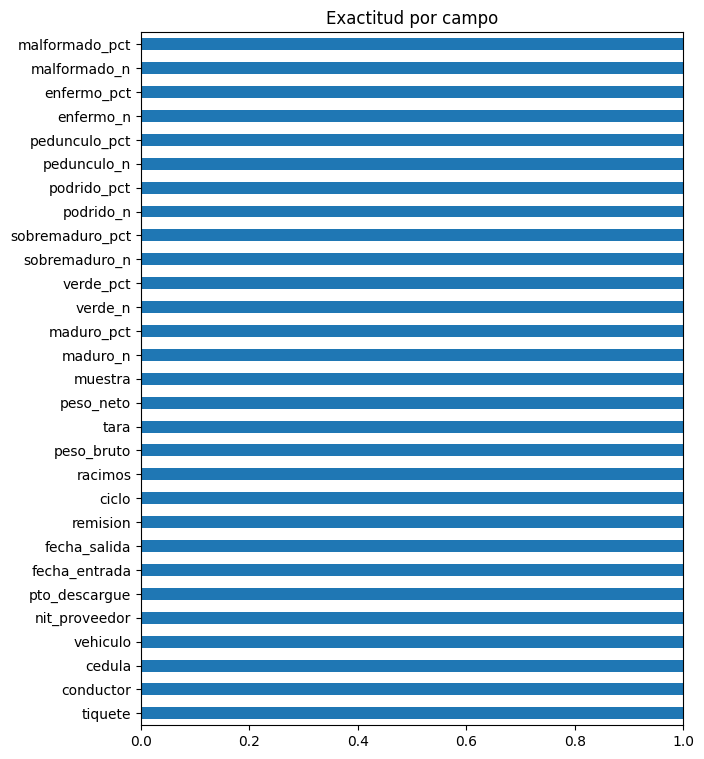

,campos_correctos,sin_errores,validacion_ok,problemas
archivo,,,,
tiquete_01.jpg,29,True,True,
tiquete_02.jpg,29,True,True,
tiquete_03.jpg,29,True,True,
tiquete_04.jpg,29,True,True,
tiquete_05.jpg,29,True,True,
tiquete_06.jpg,29,True,True,
tiquete_07.jpg,29,True,True,
tiquete_08.jpg,29,True,True,
tiquete_09.jpg,29,True,True,


In [ ]:
filas_eval = []
for ruta in FOTOS:
    predicho = normalizar_tiquete(extracciones[ruta.name]["crudo"])
    esperado = {c: real.loc[ruta.name, c] for c in CAMPOS}
    aciertos = comparar(predicho, esperado)
    problemas = validar_tiquete(predicho)
    filas_eval.append({
        "archivo": ruta.name,
        **aciertos,
        "campos_correctos": sum(aciertos.values()),
        "sin_errores": all(aciertos.values()),
        "validacion_ok": not problemas,
        "problemas": "; ".join(problemas),
    })

eval_df = pd.DataFrame(filas_eval).set_index("archivo")

print(f"Exactitud global: {eval_df[CAMPOS].to_numpy().mean():.1%} de {eval_df[CAMPOS].size} campos")
print(f"Tiquetes sin ningún error: {eval_df['sin_errores'].sum()} de {len(eval_df)}")

exactitud_campo = eval_df[CAMPOS].mean().sort_values()
exactitud_campo.plot.barh(figsize=(7, 9), xlim=(0, 1), title="Exactitud por campo")
plt.show()

display(eval_df[["campos_correctos", "sin_errores", "validacion_ok", "problemas"]])

Ahora la pregunta importante. Cruzamos dos cosas que en producción serían muy distintas:

- **¿El tiquete tiene errores?** Solo lo sabemos porque tenemos la transcripción manual.
- **¿La validación lo marcó?** Esto sí lo sabríamos siempre.

In [ ]:
cruce = pd.crosstab(
    eval_df["sin_errores"].map({True: "extracción correcta", False: "extracción con errores"}),
    eval_df["validacion_ok"].map({True: "validación: OK", False: "validación: revisar"}),
)
display(cruce)

print("Campos incorrectos en los tiquetes que la validación NO detectó:")
for archivo, fila in eval_df[~eval_df["sin_errores"] & eval_df["validacion_ok"]].iterrows():
    malos = [c for c in CAMPOS if not fila[c]]
    detalle = {c: (normalizar_tiquete(extracciones[archivo]["crudo"]).get(c), real.loc[archivo, c]) for c in malos}
    print(f"  {archivo}: {detalle}  (predicho, real)")

validacion_ok,validación: OK
sin_errores,
extracción correcta,15


Campos incorrectos en los tiquetes que la validación NO detectó:


Lee la tabla con cuidado:

- **Con errores y marcados para revisar:** la validación hizo su trabajo.
- **Correctos pero marcados:** falsa alarma. Cuestan tiempo de revisión, pero no dañan los datos.
- **Con errores y sin marcar:** es el caso peligroso. Son errores que ninguna regla puede ver, como un
  número de tiquete o una cédula mal leídos: no hay otra información en el documento con qué contrastarlos.

En un sistema real, los tiquetes marcados irían a una **cola de revisión humana**, y el resto se cargaría
automáticamente. La exactitud de la parte automática depende justamente del último caso.

#### Tarea 4: ¿Qué pasa con fotos peores?

Degradamos tres fotos de dos maneras y repetimos la extracción: 6 llamadas más.

Antes de correr la celda, **haz una predicción**: ¿qué campos crees que fallarán primero?

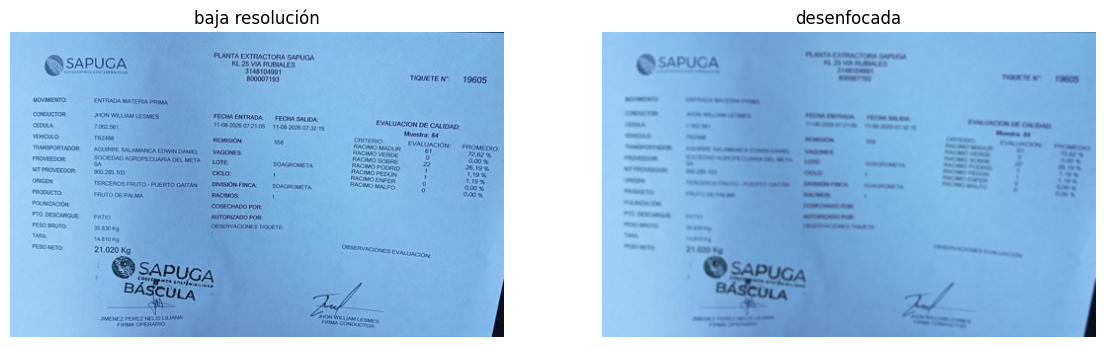

✓ tiquete_01.jpg (baja resolución): 27/29 campos correctos
✓ tiquete_01.jpg (desenfocada): 21/29 campos correctos
✓ tiquete_02.jpg (baja resolución): 28/29 campos correctos
✓ tiquete_02.jpg (desenfocada): 15/29 campos correctos
  (límite de Groq alcanzado, esperando 20 s)
  (límite de Groq alcanzado, esperando 40 s)
✓ tiquete_03.jpg (baja resolución): 26/29 campos correctos
✓ tiquete_03.jpg (desenfocada): 22/29 campos correctos


,original,baja resolución,desenfocada
tiquete,100%,100%,67%
conductor,100%,100%,33%
cedula,100%,100%,33%
vehiculo,100%,0%,0%
nit_proveedor,100%,67%,33%
fecha_entrada,100%,100%,67%
fecha_salida,100%,67%,67%
remision,100%,100%,33%
ciclo,100%,100%,67%
racimos,100%,100%,67%


Tiquetes degradados que la validación marcó: 4 de 6


In [ ]:
def degradar(ruta, tipo: str) -> io.BytesIO:
    """Genera una versión degradada de una foto."""
    imagen = Image.open(ruta).convert("RGB")
    if tipo == "baja resolución":
        imagen.thumbnail((500, 500))
    elif tipo == "desenfocada":
        imagen = imagen.filter(ImageFilter.GaussianBlur(3))
    buffer = io.BytesIO()
    imagen.save(buffer, format="JPEG", quality=85)
    buffer.seek(0)
    return buffer


PRUEBAS = FOTOS[:3]
TIPOS = ["baja resolución", "desenfocada"]

fig, ejes = plt.subplots(1, len(TIPOS), figsize=(14, 5))
for eje, tipo in zip(ejes, TIPOS):
    eje.imshow(Image.open(degradar(PRUEBAS[0], tipo)))
    eje.set_title(tipo)
    eje.axis("off")
plt.show()

filas_deg = []
for ruta in PRUEBAS:
    esperado = {c: real.loc[ruta.name, c] for c in CAMPOS}
    for tipo in TIPOS:
        try:
            predicho = normalizar_tiquete(extraer_tiquete(degradar(ruta, tipo)))
        except Exception as e:
            print(f"⚠ {ruta.name} ({tipo}): {type(e).__name__}: {e}")
            predicho = normalizar_tiquete({})
        aciertos = comparar(predicho, esperado)
        filas_deg.append({"archivo": ruta.name, "tipo": tipo, **aciertos,
                          "validacion_ok": not validar_tiquete(predicho)})
        print(f"✓ {ruta.name} ({tipo}): {sum(aciertos.values())}/{len(CAMPOS)} campos correctos")
        time.sleep(PAUSA_SEGUNDOS)

deg_df = pd.DataFrame(filas_deg)
original = eval_df.loc[[r.name for r in PRUEBAS], CAMPOS].mean()
resumen = pd.DataFrame({"original": original,
                        **{t: deg_df[deg_df["tipo"] == t][CAMPOS].mean() for t in TIPOS}})
display(resumen[(resumen < 1).any(axis=1)].style.format("{:.0%}"))
print("Tiquetes degradados que la validación marcó:", (~deg_df["validacion_ok"]).sum(), "de", len(deg_df))

## Actividad 5 (opcional): Un VLM en tu propia GPU

### Objetivo

Repetir la extracción con un VLM pequeño corriendo en Colab, como hicimos con los LLM en el Workshop 2.
Los datos de los conductores (nombre y cédula) nunca salen de tu máquina.

> Necesitas **GPU (T4)**: `Entorno de ejecución > Cambiar tipo de entorno de ejecución`. Si cambias el entorno,
> Colab reinicia la sesión y tendrás que volver a correr la configuración inicial y las Actividades 2 y 3 (las
> extracciones de la API quedan en `extracciones_vlm.json`, siempre que no borres el archivo).

Usamos `Qwen3-VL-2B-Instruct`, de unos 2.000 millones de parámetros: más de diez veces más pequeño que el
modelo de la API. Si no carga con tu versión de `transformers`, prueba con `Qwen/Qwen2.5-VL-3B-Instruct`.

In [ ]:
!pip install -q -U transformers accelerate

import torch
from transformers import AutoModelForImageTextToText, AutoProcessor

MODELO_LOCAL = "Qwen/Qwen3-VL-2B-Instruct"

if torch.cuda.is_available():
    processor = AutoProcessor.from_pretrained(MODELO_LOCAL)
    modelo_local = AutoModelForImageTextToText.from_pretrained(
        MODELO_LOCAL, dtype=torch.float16, device_map="cuda"
    )
    print(f"✓ {MODELO_LOCAL} cargado. Memoria usada: {torch.cuda.memory_allocated() / 1e9:.1f} GB")
else:
    print("✗ No hay GPU: esta actividad necesita un entorno con GPU (T4).")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 112.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 38.8 MB/s eta 0:00:00


preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/5.50k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.50k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/10.9k [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 4.26GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

✓ Qwen/Qwen3-VL-2B-Instruct cargado. Memoria usada: 4.3 GB


In [ ]:
def extraer_tiquete_local(ruta, lado_maximo: int = 1280, max_new_tokens: int = 900) -> dict:
    """Extrae los campos de un tiquete con el VLM local."""
    imagen = Image.open(ruta).convert("RGB")
    imagen.thumbnail((lado_maximo, lado_maximo))
    mensajes = [{"role": "user", "content": [
        {"type": "image", "image": imagen},
        {"type": "text", "text": PROMPT_EXTRACCION},
    ]}]
    entradas = processor.apply_chat_template(
        mensajes, tokenize=True, add_generation_prompt=True, return_dict=True, return_tensors="pt"
    ).to(modelo_local.device)
    with torch.inference_mode():
        salida = modelo_local.generate(**entradas, max_new_tokens=max_new_tokens, do_sample=False)
    texto = processor.decode(salida[0, entradas["input_ids"].shape[1]:], skip_special_tokens=True)
    return parsear_json(texto)


if torch.cuda.is_available():
    filas_local = []
    for ruta in FOTOS[:5]:
        inicio = time.time()
        try:
            predicho = normalizar_tiquete(extraer_tiquete_local(ruta))
        except Exception as e:
            print(f"⚠ {ruta.name}: {type(e).__name__}: {e}")
            predicho = normalizar_tiquete({})
        segundos = time.time() - inicio
        aciertos = comparar(predicho, {c: real.loc[ruta.name, c] for c in CAMPOS})
        filas_local.append({
            "archivo": ruta.name,
            "local_correctos": sum(aciertos.values()),
            "api_correctos": eval_df.loc[ruta.name, "campos_correctos"],
            "local_segundos": round(segundos, 1),
            "api_segundos": extracciones[ruta.name]["segundos"],
            "local_validacion_ok": not validar_tiquete(predicho),
        })
        print(f"✓ {ruta.name}: {sum(aciertos.values())}/{len(CAMPOS)} campos en {segundos:.0f} s")
    display(pd.DataFrame(filas_local).set_index("archivo"))

✓ tiquete_01.jpg: 29/29 campos en 62 s
✓ tiquete_02.jpg: 28/29 campos en 22 s
✓ tiquete_03.jpg: 29/29 campos en 22 s
✓ tiquete_04.jpg: 28/29 campos en 30 s
✓ tiquete_05.jpg: 27/29 campos en 42 s


,local_correctos,api_correctos,local_segundos,api_segundos,local_validacion_ok
archivo,,,,,
tiquete_01.jpg,29,29,61.6,1.4,True
tiquete_02.jpg,28,29,21.8,1.4,True
tiquete_03.jpg,29,29,21.5,1.8,True
tiquete_04.jpg,28,29,30.2,2.6,True
tiquete_05.jpg,27,29,42.4,3.6,False


## Del notebook a producción: la demo de n8n

En clase veremos este mismo flujo armado en **n8n**, una herramienta para automatizar procesos conectando
servicios sin escribir una aplicación completa:

```text
Foto enviada por Telegram
  → descargar la imagen
  → VLM de Groq con PROMPT_EXTRACCION
  → normalizar y validar (nodo de código)
  ├─ sin problemas → agregar fila en Google Sheets
  └─ con problemas → agregar fila en la hoja "Por revisar" y avisar al despacho
```

Todo lo que construiste aquí tiene un lugar en ese flujo: el prompt, el lector de JSON, la normalización y,
sobre todo, las validaciones que deciden qué pasa sin revisión y qué va a una persona.

### Preguntas para discutir

**1. ¿Por qué le pedimos al modelo copiar los valores tal como aparecen, en vez de pedirle números ya
convertidos?**

**R.** Porque así separamos dos tipos de error. Si el modelo convierte `32.280` en `32.28`, no sabemos si
leyó mal o convirtió mal. Si copia el texto, podemos auditar la lectura contra la foto, y la conversión queda en
código determinista, que se prueba una vez y funciona igual siempre. Además, el formato colombiano (punto de
miles, coma decimal) es exactamente el tipo de detalle en el que un modelo puede equivocarse.

**2. Las validaciones detectan errores sin conocer la respuesta. ¿Qué errores no pueden detectar?**

**R.** Los que no dejan rastro en otra parte del documento: el número de tiquete, la remisión, la cédula, la
placa, o una fecha que sigue siendo válida. También un error "consistente": si el modelo lee mal el peso bruto
y el neto de forma que la resta siga cuadrando. Para esos campos hacen falta otras fuentes, como el listado de
placas de la flota o el sistema de la báscula.

**3. Con 15 tiquetes, ¿qué tan confiable es la exactitud que medimos?**

**R.** Poco. Cada tiquete pesa casi 7 puntos porcentuales en el indicador "tiquetes sin errores", y varios
campos son iguales en todas las fotos (conductor, placa, NIT), lo que infla la exactitud por campo. Antes de
confiar en el sistema habría que evaluarlo con cientos de fotos, de distintos conductores, plantas y
condiciones de luz.

**4. ¿API o modelo local para este caso?**

**R.** La API es más precisa y no requiere infraestructura, pero envía a un tercero datos personales (nombre y
cédula del conductor), tiene límites de uso y el modelo está en *preview*: puede desaparecer sin mucho aviso.
El modelo local mantiene los datos en casa y no depende de nadie, pero es más lento en una T4 y suele
equivocarse más. Una opción intermedia es usar la API y enmascarar los campos personales, o usar el modelo local
solo para los campos no sensibles.

**5. ¿Cómo conectarías estos datos con el Manual Operativo del Workshop 5?**

**R.** Con reglas de negocio adicionales: comparar el peso neto con el peso reportado por la finca (la
diferencia no debe superar el 2 %), verificar que el peso no supere el límite del tipo de vehículo, y controlar
que la foto se haya subido antes de salir de la planta. Algunas de esas reglas se pueden responder con el RAG
del Workshop 5.

## Extensiones opcionales

- **Salida estructurada con Pydantic:** define un modelo `Tiquete` con tipos y úsalo para validar el JSON del
  VLM antes de normalizarlo.
- **Autocorrección:** si `validar_tiquete` encuentra problemas, vuelve a llamar al modelo con la foto y la lista
  de problemas, y pídele que revise esos campos. Mide si mejora o si "inventa" valores para que cuadren.
- **Recortes:** envía dos imágenes por tiquete (la foto completa y un recorte ampliado de la tabla de calidad)
  y compara la exactitud de esa tabla.
- **Votación:** extrae cada tiquete tres veces y quédate, campo por campo, con el valor más repetido.
- **Confianza del OCR como apoyo:** usa `pytesseract.image_to_data` para verificar que los números que devolvió
  el VLM aparecen en el texto del OCR.
- **Reglas de negocio:** agrega la tolerancia del 2 % y el límite de 34 toneladas del Manual Operativo.
- **Más datos:** fotografía nuevos tiquetes, transcríbelos y amplía la evaluación.

## Resumen

```text
Foto → VLM (copiar lo impreso) → JSON → normalizar (código) → validar (reglas) ─┬─ OK → tabla
                                                                                   └─ revisar → persona
```

Las ideas centrales:

- **El OCR lee, pero no entiende la estructura:** en fotos con columnas, las etiquetas y los valores se separan.
- **Un VLM lee y relaciona a la vez**, pero se puede equivocar en silencio.
- **El modelo transcribe; el código convierte.** Así cada error queda en un lugar identificable.
- **Las reglas del propio documento** permiten detectar muchos errores sin conocer la respuesta, pero no todos.
- **Evalúa con datos reales y en cantidad suficiente** antes de confiar en la automatización.